In [1]:
# Cell 1 — Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tell matplotlib to show charts inside the notebook
%matplotlib inline

# Load the dataset we generated with seed.py
df = pd.read_csv("data/students.csv")

# Confirm it loaded correctly
print(f"Dataset shape: {df.shape}")  # should say (1000, 9)
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape: (1000, 9)

Column names: ['name', 'gender', 'attendance_rate', 'avg_grade', 'absences_last_month', 'distance_km', 'num_siblings', 'fee_arrears', 'dropped_out']

First 3 rows:


,name,gender,attendance_rate,avg_grade,absences_last_month,distance_km,num_siblings,fee_arrears,dropped_out
0,Purity Njoroge,M,82.5,83.2,13,3.2,6,1835,0
1,Dennis Rotich,F,72.9,74.6,14,5.3,7,1935,0
2,Cynthia Owino,M,84.7,59.1,5,4.1,7,4584,0


In [2]:
# Cell 2 — Data quality check
# Before any analysis, we must verify:
# 1. Every column has the right data type
# 2. There are no missing values

print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values Per Column ===")
print(df.isnull().sum())

print("\n=== Dropout Distribution ===")
counts = df["dropped_out"].value_counts()
print(f"Stayed (0):      {counts[0]} students ({counts[0]/len(df)*100:.1f}%)")
print(f"Dropped out (1): {counts[1]} students ({counts[1]/len(df)*100:.1f}%)")

=== Data Types ===
name                       str
gender                     str
attendance_rate        float64
avg_grade              float64
absences_last_month      int64
distance_km            float64
num_siblings             int64
fee_arrears              int64
dropped_out              int64
dtype: object

=== Missing Values Per Column ===
name                   0
gender                 0
attendance_rate        0
avg_grade              0
absences_last_month    0
distance_km            0
num_siblings           0
fee_arrears            0
dropped_out            0
dtype: int64

=== Dropout Distribution ===
Stayed (0):      816 students (81.6%)
Dropped out (1): 184 students (18.4%)


In [3]:
# Cell 3 — Statistical summary
# .describe() gives us count, mean, std, min, max and quartiles
# for every numerical column.
# This tells us if any values look suspicious or out of range.

df.describe().round(2)

,attendance_rate,avg_grade,absences_last_month,distance_km,num_siblings,fee_arrears,dropped_out
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,74.96,59.21,6.84,4.78,3.51,2965.60,0.18
std,13.99,17.80,4.25,4.86,2.33,3076.61,0.39
min,26.40,5.10,0.00,0.00,0.00,2.00,0.00
25%,65.28,47.10,3.00,1.40,1.00,802.75,0.00
50%,75.40,59.15,7.00,3.30,4.00,1970.00,0.00
75%,84.70,71.12,10.00,6.62,6.00,4116.50,0.00
max,100.00,100.00,14.00,30.20,7.00,20000.00,1.00


In [4]:
# Cell 4 — Dropout rate by gender
# Kenya research shows girls drop out at higher rates.
# Let's verify our synthetic data reflects this.

gender_dropout = df.groupby("gender")["dropped_out"].mean() * 100
print("=== Dropout Rate by Gender ===")
print(f"Male (M):   {gender_dropout['M']:.1f}%")
print(f"Female (F): {gender_dropout['F']:.1f}%")

=== Dropout Rate by Gender ===
Male (M):   17.5%
Female (F): 19.3%


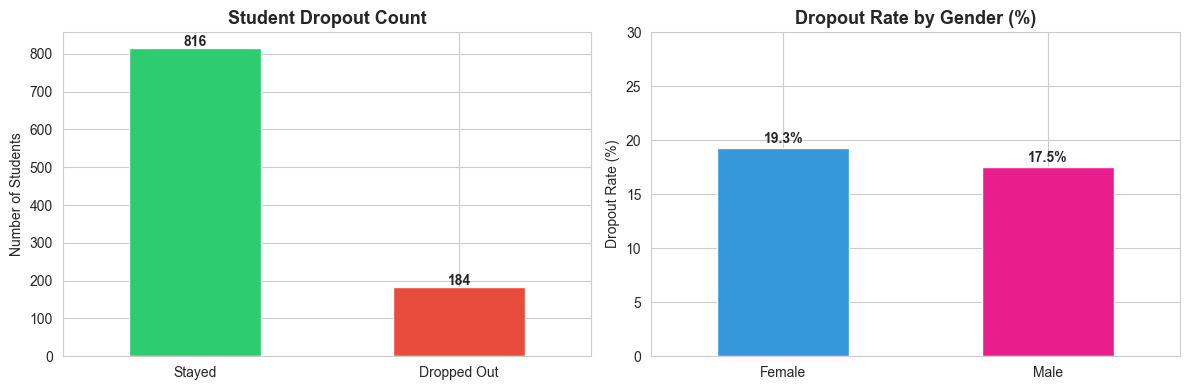

Chart saved to plots/dropout_overview.png


In [5]:
# Cell 5 — Visualize dropout distribution
# A bar chart showing how many students stayed vs dropped out.
# This is the first plot that will go into your README.

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Chart 1: Overall dropout count ---
colors = ["#2ecc71", "#e74c3c"]  # green = stayed, red = dropped out
df["dropped_out"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=colors,
    edgecolor="white"
)
axes[0].set_title("Student Dropout Count", fontsize=13, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["Stayed", "Dropped Out"], rotation=0)
axes[0].set_ylabel("Number of Students")

# Add count labels on top of each bar
for i, v in enumerate(df["dropped_out"].value_counts()):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# --- Chart 2: Dropout rate by gender ---
gender_data = df.groupby("gender")["dropped_out"].mean() * 100
gender_data.plot(
    kind="bar",
    ax=axes[1],
    color=["#3498db", "#e91e8c"],
    edgecolor="white"
)
axes[1].set_title("Dropout Rate by Gender (%)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_xticklabels(["Female", "Male"], rotation=0)
axes[1].set_ylabel("Dropout Rate (%)")
axes[1].set_ylim(0, 30)

for i, v in enumerate(gender_data):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("plots/dropout_overview.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to plots/dropout_overview.png")

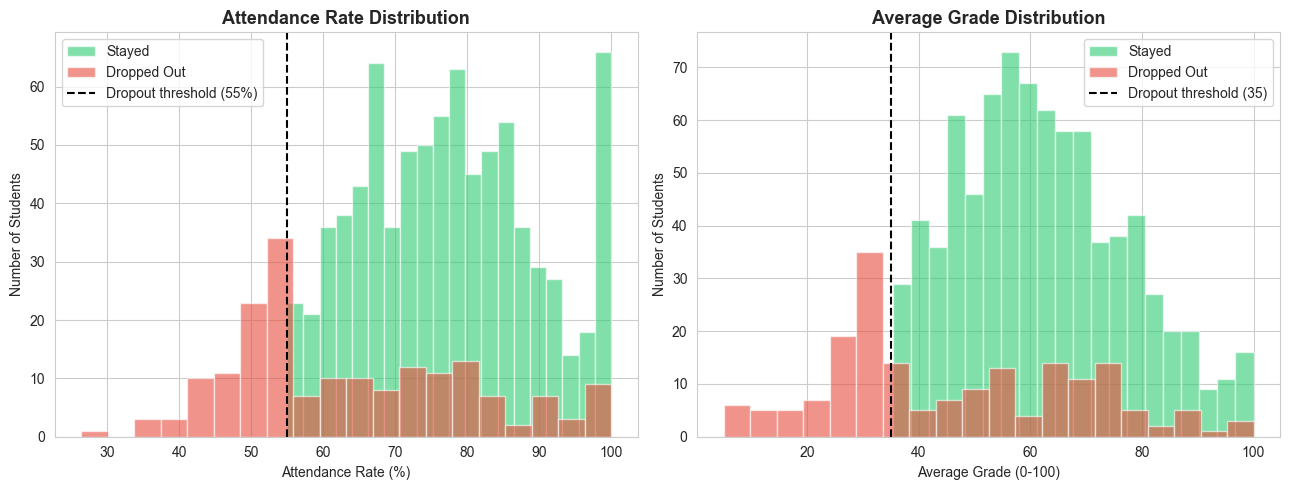

Chart saved to plots/attendance_grade_distribution.png


In [6]:
# Cell 6 — Attendance and Grade distributions by dropout status
# This is the most revealing chart — it shows visually WHY
# attendance and grades are the strongest predictors.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Chart 1: Attendance rate by dropout status ---
df[df["dropped_out"] == 0]["attendance_rate"].hist(
    ax=axes[0], bins=20, alpha=0.6, color="#2ecc71", label="Stayed"
)
df[df["dropped_out"] == 1]["attendance_rate"].hist(
    ax=axes[0], bins=20, alpha=0.6, color="#e74c3c", label="Dropped Out"
)
axes[0].set_title("Attendance Rate Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Attendance Rate (%)")
axes[0].set_ylabel("Number of Students")
axes[0].legend()
axes[0].axvline(x=55, color="black", linestyle="--", linewidth=1.5,
                label="Dropout threshold (55%)")
axes[0].legend()

# --- Chart 2: Average grade by dropout status ---
df[df["dropped_out"] == 0]["avg_grade"].hist(
    ax=axes[1], bins=20, alpha=0.6, color="#2ecc71", label="Stayed"
)
df[df["dropped_out"] == 1]["avg_grade"].hist(
    ax=axes[1], bins=20, alpha=0.6, color="#e74c3c", label="Dropped Out"
)
axes[1].set_title("Average Grade Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Average Grade (0-100)")
axes[1].set_ylabel("Number of Students")
axes[1].legend()
axes[1].axvline(x=35, color="black", linestyle="--", linewidth=1.5,
                label="Dropout threshold (35)")
axes[1].legend()

plt.tight_layout()
plt.savefig("plots/attendance_grade_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to plots/attendance_grade_distribution.png")

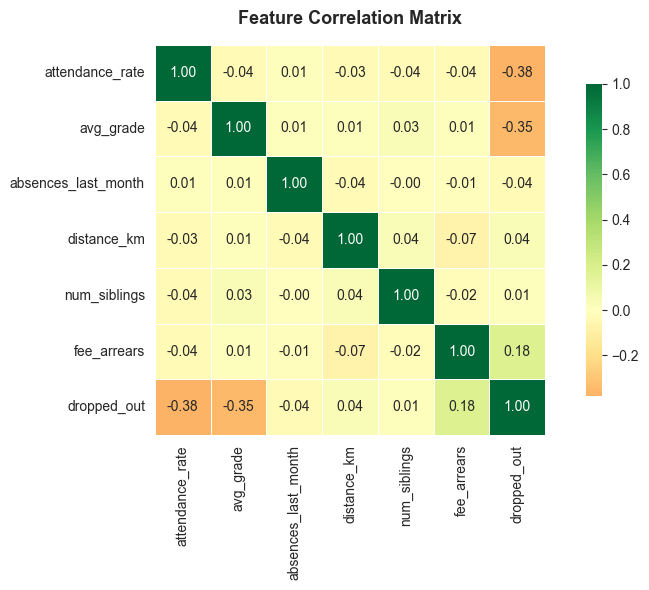


=== Correlation with dropout (strongest to weakest) ===
attendance_rate       -0.38
avg_grade             -0.35
absences_last_month   -0.04
num_siblings           0.01
distance_km            0.04
fee_arrears            0.18
Name: dropped_out, dtype: float64


In [7]:
# Cell 7 — Correlation heatmap
# Correlation measures how strongly two variables move together.
# Range: -1.0 (perfect opposite) to +1.0 (perfect together)
# We want to see which features correlate most with dropped_out.

# We can only correlate numbers, so drop the text columns
numeric_df = df.drop(columns=["name", "gender"])

# Compute correlation matrix
corr_matrix = numeric_df.corr().round(2)

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr_matrix,
    annot=True,           # show numbers inside each box
    fmt=".2f",            # 2 decimal places
    cmap="RdYlGn",        # red = negative, yellow = neutral, green = positive
    center=0,             # center the color scale at 0
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("plots/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print just the correlations with dropped_out, sorted
print("\n=== Correlation with dropout (strongest to weakest) ===")
print(corr_matrix["dropped_out"].drop("dropped_out").sort_values())

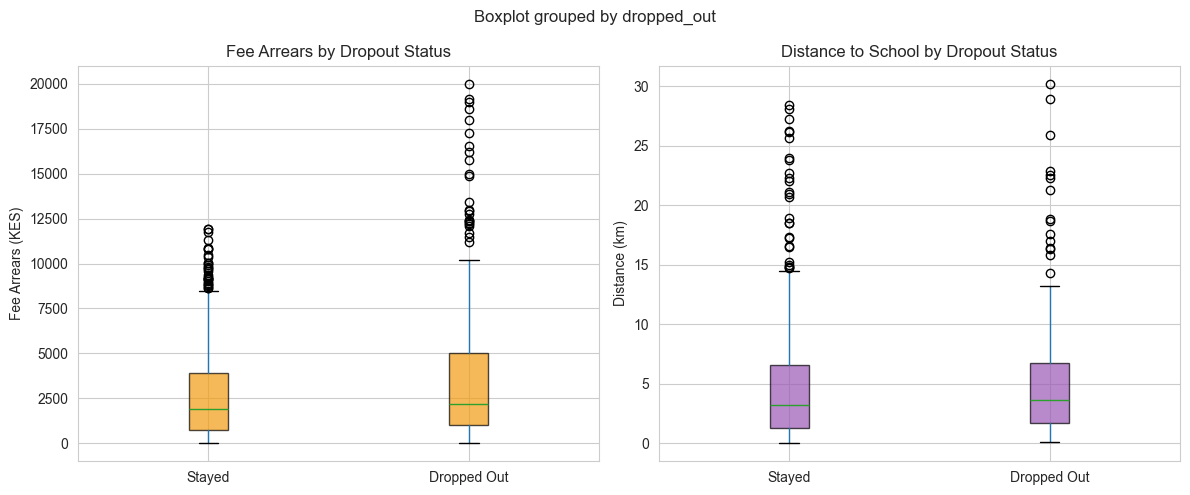

Chart saved to plots/boxplots_fee_distance.png ✅

=== EDA Complete ===
Plots saved:
  - plots/dropout_overview.png
  - plots/attendance_grade_distribution.png
  - plots/correlation_matrix.png
  - plots/boxplots_fee_distance.png


In [8]:
# Cell 8 — Box plots: fee arrears and distance by dropout status
# Box plots show the spread of values for each group.
# The box = middle 50% of values
# The line inside = median
# The whiskers = full range (excluding outliers)
# Dots outside whiskers = outliers

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Chart 1: Fee arrears by dropout status ---
df.boxplot(
    column="fee_arrears",
    by="dropped_out",
    ax=axes[0],
    patch_artist=True,
    boxprops=dict(facecolor="#f39c12", alpha=0.7)
)
axes[0].set_title("Fee Arrears by Dropout Status", fontsize=12, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_xticklabels(["Stayed", "Dropped Out"])
axes[0].set_ylabel("Fee Arrears (KES)")
plt.sca(axes[0])
plt.title("Fee Arrears by Dropout Status")

# --- Chart 2: Distance by dropout status ---
df.boxplot(
    column="distance_km",
    by="dropped_out",
    ax=axes[1],
    patch_artist=True,
    boxprops=dict(facecolor="#9b59b6", alpha=0.7)
)
axes[1].set_title("Distance to School by Dropout Status", fontsize=12, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_xticklabels(["Stayed", "Dropped Out"])
axes[1].set_ylabel("Distance (km)")
plt.sca(axes[1])
plt.title("Distance to School by Dropout Status")

plt.tight_layout()
plt.savefig("plots/boxplots_fee_distance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to plots/boxplots_fee_distance.png ✅")
print("\n=== EDA Complete ===")
print("Plots saved:")
print("  - plots/dropout_overview.png")
print("  - plots/attendance_grade_distribution.png")
print("  - plots/correlation_matrix.png")
print("  - plots/boxplots_fee_distance.png")